In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
bids_folder = Path('/data/ds-neuralpriors')
pars_ground_truth = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models2' / 'group_roi-NPCr_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models2' / 'group_roi-NPCr_desc-responses_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

pars = pd.concat([pars_ground_truth, pars_estimates], keys=['ground_truth', 'estimates'], names=['type'], axis=0)


# rename index level subject_id to subject
pars.index.set_names('subject', level='subject_id', inplace=True)

pars.index.unique(level='smoothed')

Index([True], dtype='bool', name='smoothed')

In [102]:
pars.index.unique(level='model_label')

Index([0, 3, 4, 5, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], dtype='int64', name='model_label')

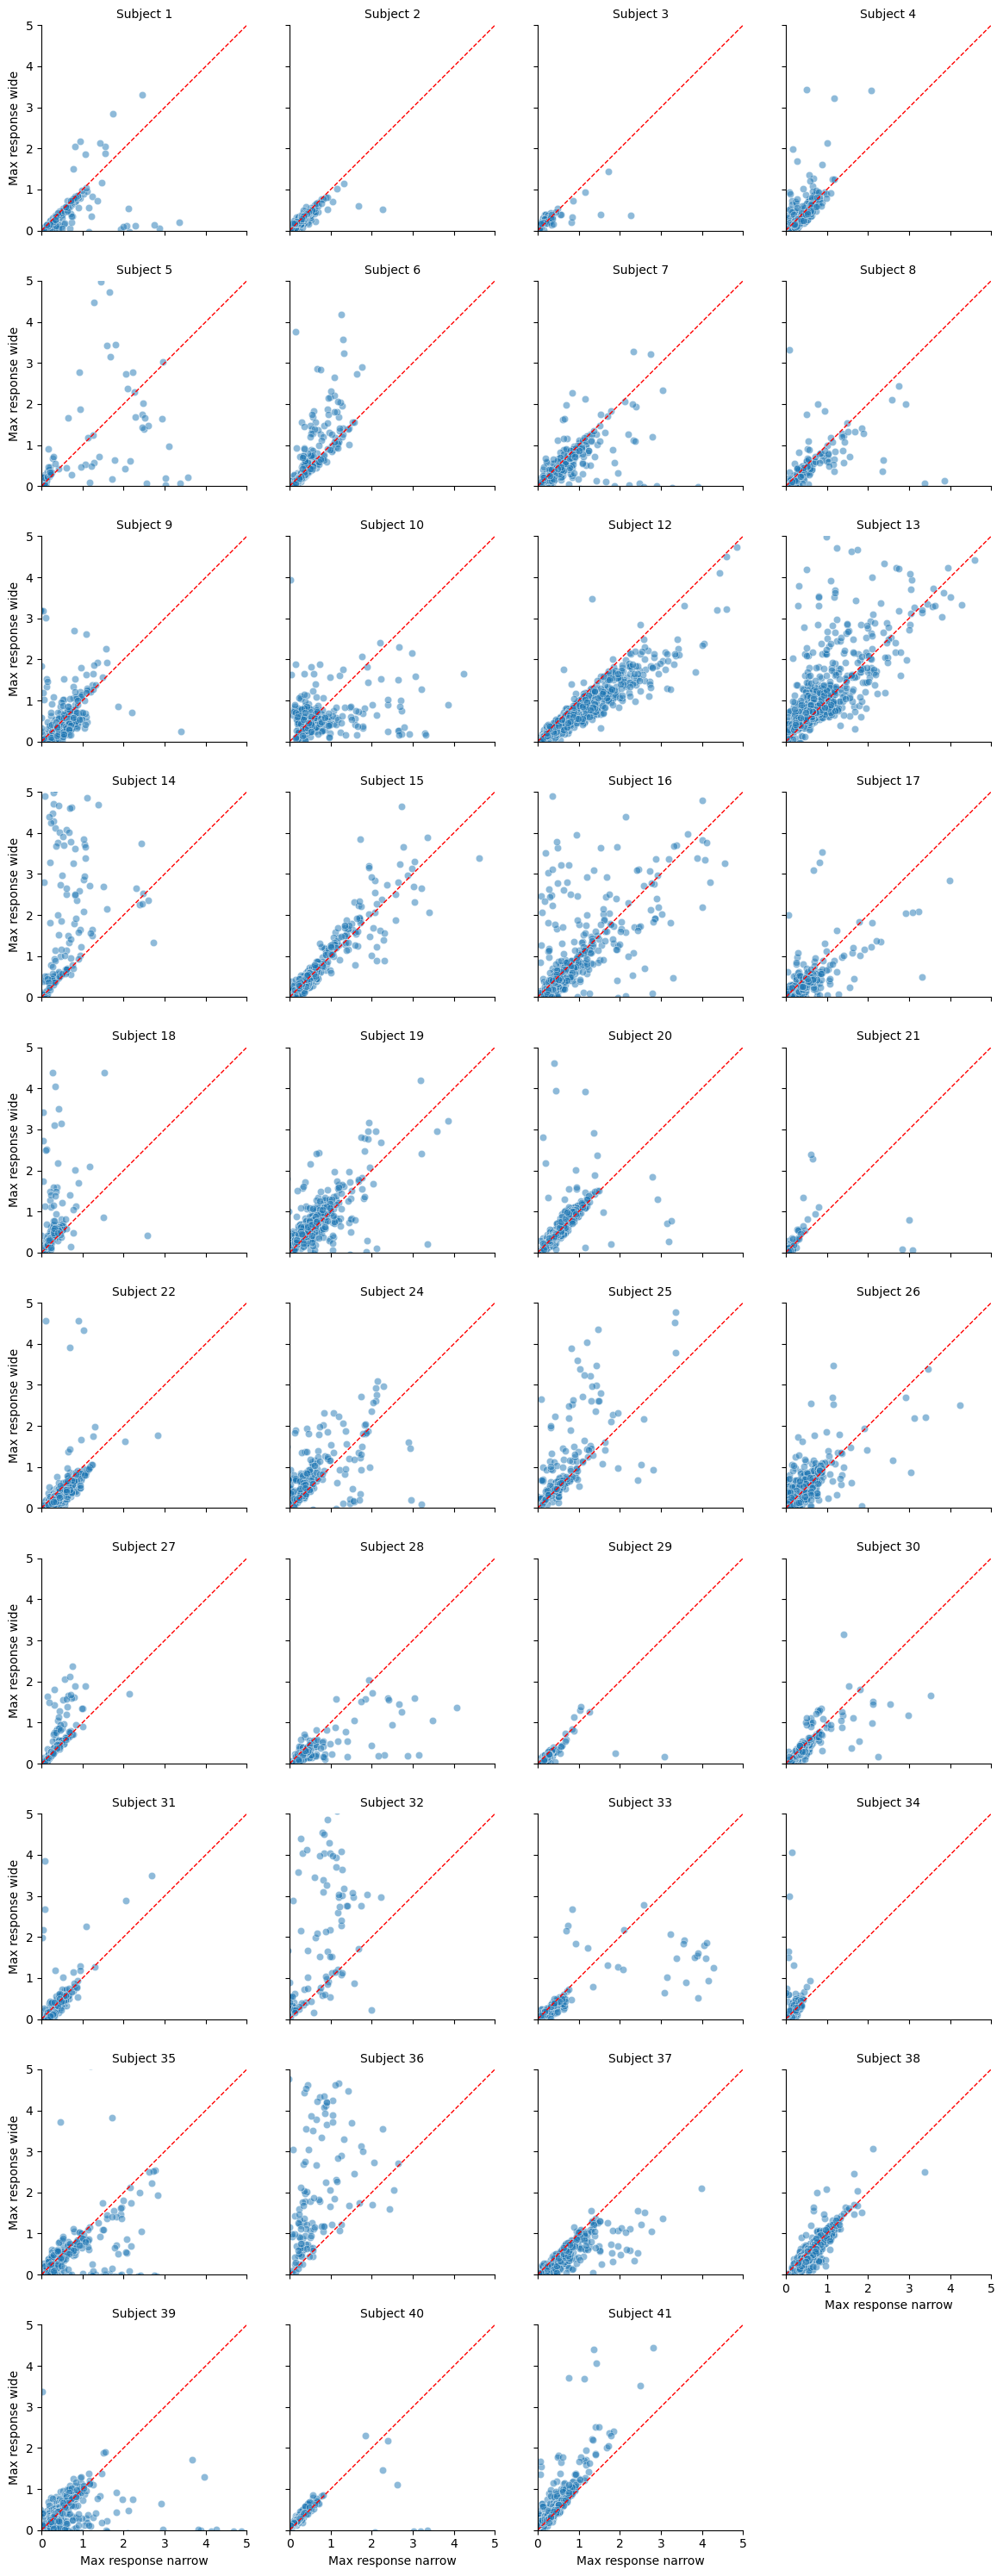

In [103]:
tmp = pars.xs(12, level='model_label')

tmp = tmp[tmp[('cvr2', 'nan')] > 0.0]


max_response_narrow = tmp[('amplitude', 'narrow')] + tmp[('baseline', 'narrow')]
max_response_wide = tmp[('amplitude', 'wide')] + tmp[('baseline', 'wide')]

max_responses = pd.concat([max_response_narrow, max_response_wide], axis=1)
max_responses.columns = ['narrow', 'wide']

g = sns.FacetGrid(max_responses.reset_index(), col='subject', col_wrap=4, height=3, aspect=1)

g.map_dataframe(sns.scatterplot, x='narrow', y='wide', alpha=0.5)

g.set(xlim=(0, 5), ylim=(0, 5))
g.set_axis_labels('Max response narrow', 'Max response wide')

g.set_titles(col_template='Subject {col_name}')

# identity line
x = np.linspace(0, 5, 100)
y = x
for ax in g.axes.flat:
    ax.plot(x, y, color='red', linestyle='--', linewidth=1)
    ax.set_aspect('equal', adjustable='box')

<Axes: xlabel='narrow', ylabel='Count'>

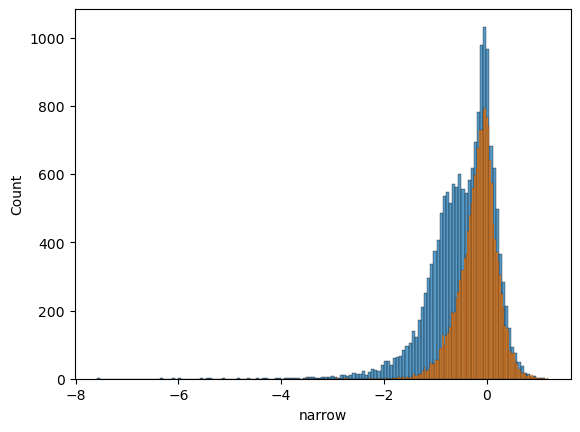

In [78]:
sns.histplot(tmp['baseline']['narrow'])
sns.histplot(tmp['baseline']['wide'])   

<Axes: xlabel='narrow', ylabel='Count'>

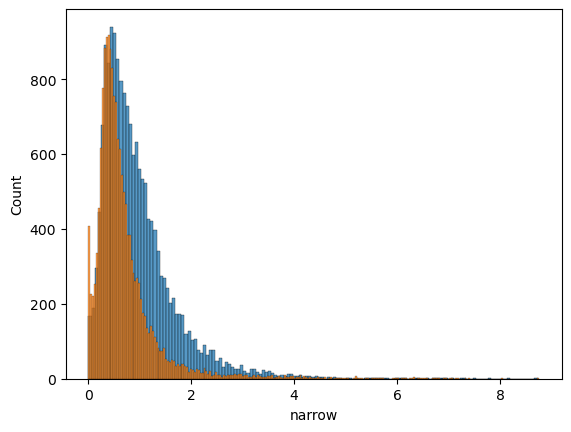

In [79]:
sns.histplot(tmp['amplitude']['narrow'])
sns.histplot(tmp['amplitude']['wide'])   

<Axes: xlabel='narrow', ylabel='Count'>

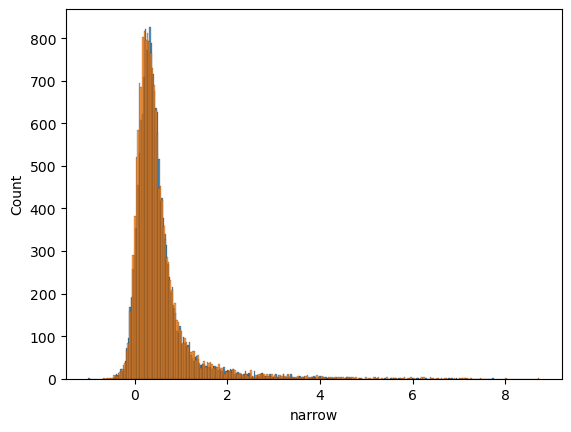

In [80]:
sns.histplot(tmp['amplitude']['narrow'] + tmp['baseline']['narrow'])
sns.histplot(tmp['amplitude']['wide'] + tmp['baseline']['wide'])

In [81]:
pars.groupby(['model_label']).mean()

parameter           mu                   sd           delta_wide            \
range           narrow       wide    narrow      wide     narrow      wide   
model_label                                                                  
0            16.076200  16.076200  0.554674  0.554674   1.000000  1.000000   
3            15.336028  18.241301  0.629938  0.629938   1.475116  1.475116   
4            14.409137  19.384285  0.551656  0.551656   2.000000  2.000000   
5            15.813152  21.458009  0.734014  0.734014   2.345696  2.345696   
12           14.360055  20.059932  0.881276  0.881276   2.000000  2.000000   
13           13.978115  19.706033  0.966074  0.966074   2.000000  2.000000   
14           14.046261  18.772576  1.307411  1.568861   2.000000  2.000000   
15           14.533285  20.123180  0.805376  1.007032   2.000000  2.000000   
16           14.131195  19.815133  0.886294  0.886294   2.000000  2.000000   
17           14.214331  19.858674  1.018714  1.105365   2.000000  2.000000   
18           16.410230  23.879576  0.853544  1.108857   2.230193  2.230193   
19           15.874985  22.790167  0.983625  0.983625   2.416255  2.416255   
20           15.894873  22.615070  0.999691  1.223456   2.462425  2.462425   

parameter   amplitude            baseline             alpha          \
range          narrow      wide    narrow      wide  narrow    wide   
model_label                                                           
0            0.538133  0.538133 -0.125805 -0.125805  0.0001  0.0001   
3            0.773261  0.773261 -0.251007 -0.251007  0.0001  0.0001   
4            0.586357  0.586357 -0.132082 -0.132082  0.0001  0.0001   
5            0.627166  0.627166 -0.178803 -0.178803  0.0001  0.0001   
12           0.791436  0.714182 -0.333231 -0.189976  0.0001  0.0001   
13           0.835010  0.769090  0.011287  0.011287  0.0001  0.0001   
14           0.805423  0.805423 -0.345455 -0.345455  0.0001  0.0001   
15           0.756331  0.756331 -0.250190 -0.250190     NaN     NaN   
16           0.701332  0.557144 -0.337649 -0.214528     NaN     NaN   
17           0.716438  0.621222 -0.365364 -0.285279     NaN     NaN   
18           0.729037  0.729037 -0.252142 -0.252142     NaN     NaN   
19           0.715417  0.554117 -0.362943 -0.232800     NaN     NaN   
20           0.730277  0.612653 -0.385895 -0.292564     NaN     NaN   

parameter   lower_bound_range                   r2      cvr2 baseline_ratio  \
range                  narrow       wide       nan       nan         narrow   
model_label                                                                   
0                   10.000000  10.000000  0.018813 -0.007372            NaN   
3                   10.602332  10.602332  0.024378 -0.010899            NaN   
4                   10.000000  10.000000  0.020174 -0.005818            NaN   
5                   10.000000  10.000000  0.020688 -0.006301            NaN   
12                  10.000000  10.000000  0.022653 -0.006471            NaN   
13                  10.000000  10.000000  0.021078 -0.005647       0.447075   
14                  10.000000  10.000000  0.022378 -0.006995            NaN   
15                        NaN        NaN  0.019386 -0.003449            NaN   
16                        NaN        NaN  0.020264 -0.004919            NaN   
17                        NaN        NaN  0.020566 -0.005250            NaN   
18                        NaN        NaN  0.019737 -0.004005            NaN   
19                        NaN        NaN  0.020589 -0.005575            NaN   
20                        NaN        NaN  0.020949 -0.005354            NaN   

parameter              
range            wide  
model_label            
0                 NaN  
3                 NaN  
4                 NaN  
5                 NaN  
12                NaN  
13           0.447075  
14                NaN  
15                NaN  
16                NaN  
17                NaN  
18                NaN  
19           

Text(0.5, 0.98, 'Proportion of voxels with CVR2 > 0')

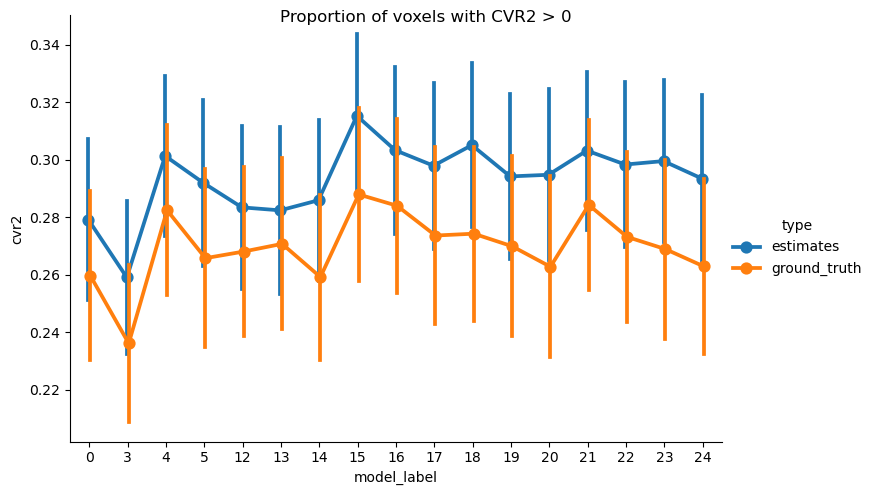

In [104]:
cvr2 = pars[('cvr2', 'nan')].to_frame('cvr2')

cvr2_proportion = cvr2.groupby(['subject', 'model_label', 'type']).apply(lambda x: (x > 0.0).mean())

sns.catplot(x='model_label', y='cvr2', data=cvr2_proportion.reset_index(), kind='point', errorbar='se', aspect=1.5, 
            hue='type', dodge=True)
plt.suptitle('Proportion of voxels with CVR2 > 0')

Text(0.5, 1.0, 'SDs of nPRFs (estimates, model 15)')

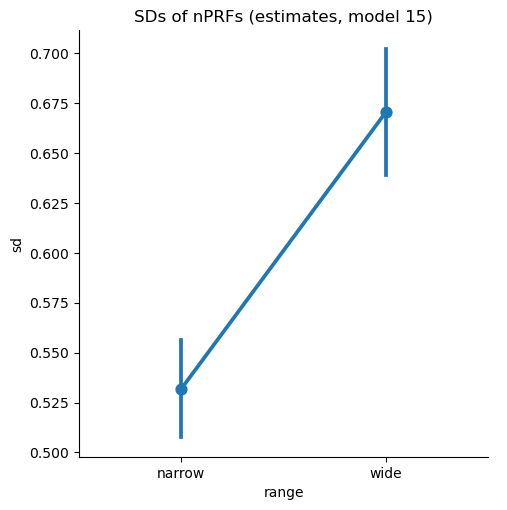

In [119]:
amp = pars[pars[('cvr2', 'nan')] > 0.0 ].xs(15, level='model_label').xs('estimates', level='type').xs('sd', level=0, axis=1).stack().to_frame('sd')

sns.catplot(x='range', y='sd', data=amp.groupby(['subject', 'range']).mean(), kind='point', errorbar='se')

plt.title('SDs of nPRFs (estimates, model 15)')

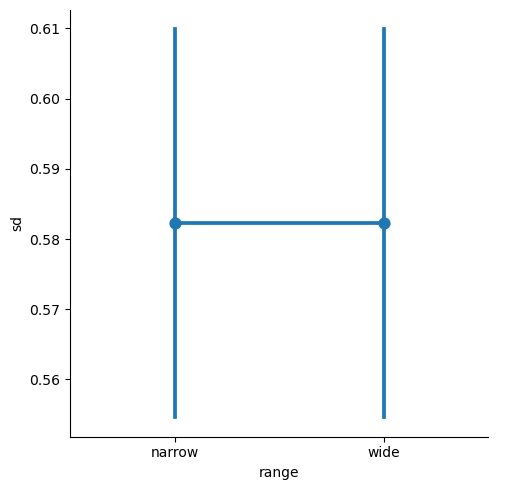

In [116]:
amp = pars[pars[('cvr2', 'nan')] > 0.0 ].xs(21, level='model_label').xs('estimates', level='type').xs('sd', level=0, axis=1).stack().to_frame('sd')

sns.catplot(x='range', y='sd', data=amp.groupby(['subject', 'range']).mean(), kind='point', errorbar='se')

Text(0.5, 1.0, 'Amplitude of nPRFs (estimates, model 21)')

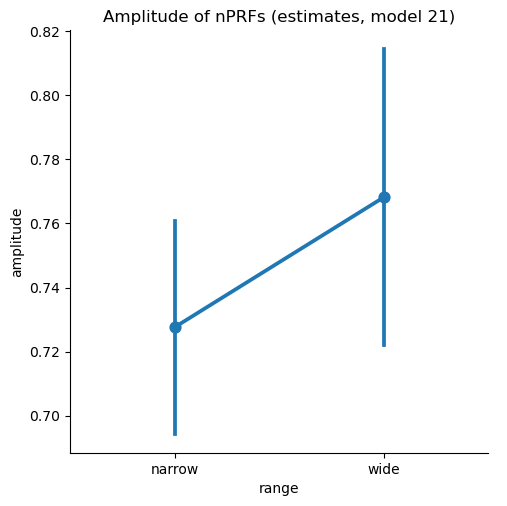

In [120]:
amp = pars[pars[('cvr2', 'nan')] > 0.0 ].xs(21, level='model_label').xs('estimates', level='type').xs('amplitude', level=0, axis=1).stack().to_frame('amplitude')

sns.catplot(x='range', y='amplitude', data=amp.groupby(['subject', 'range']).mean(), kind='point', errorbar='se')

plt.title('Amplitude of nPRFs (estimates, model 21)')

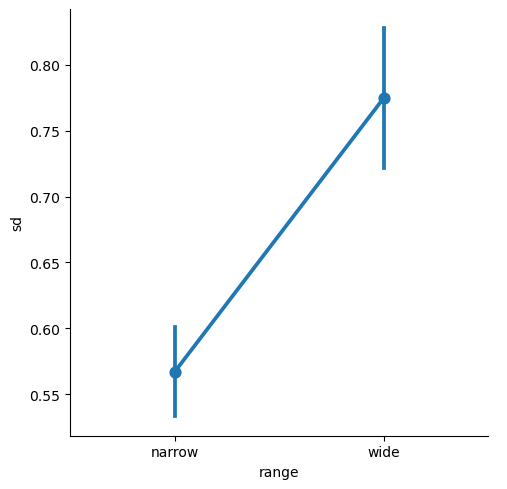

In [118]:
amp = pars[pars[('cvr2', 'nan')] > 0.0 ].xs(22, level='model_label').xs('estimates', level='type').xs('sd', level=0, axis=1).stack().to_frame('sd')

sns.catplot(x='range', y='sd', data=amp.groupby(['subject', 'range']).mean(), kind='point', errorbar='se')

Text(0.5, 0.98, 'Median CVR2')

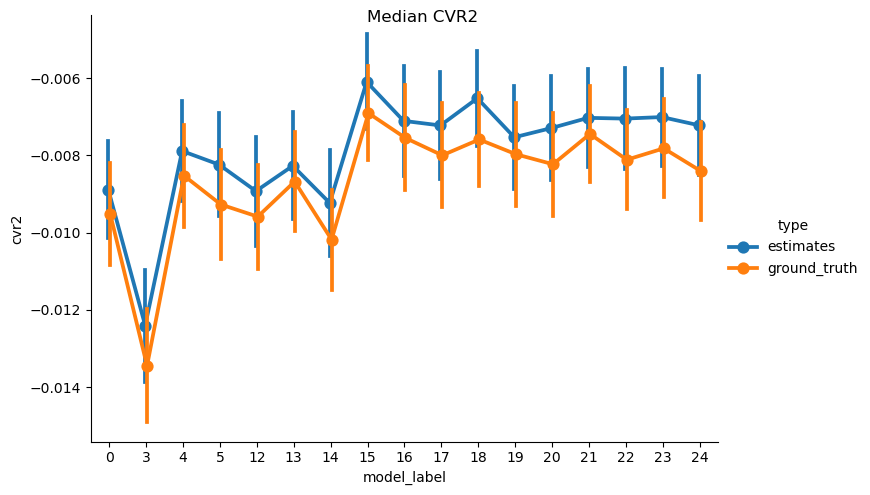

In [105]:
cvr2 = pars[('cvr2', 'nan')].to_frame('cvr2')

cvr2_proportion = cvr2.groupby(['subject', 'model_label', 'type']).median()

sns.catplot(x='model_label', y='cvr2', data=cvr2_proportion.reset_index(), kind='point', errorbar='se', aspect=1.5, 
            hue='type', dodge=True)
plt.suptitle('Median CVR2')

Text(0.5, 0.98, 'Mean CVR2')

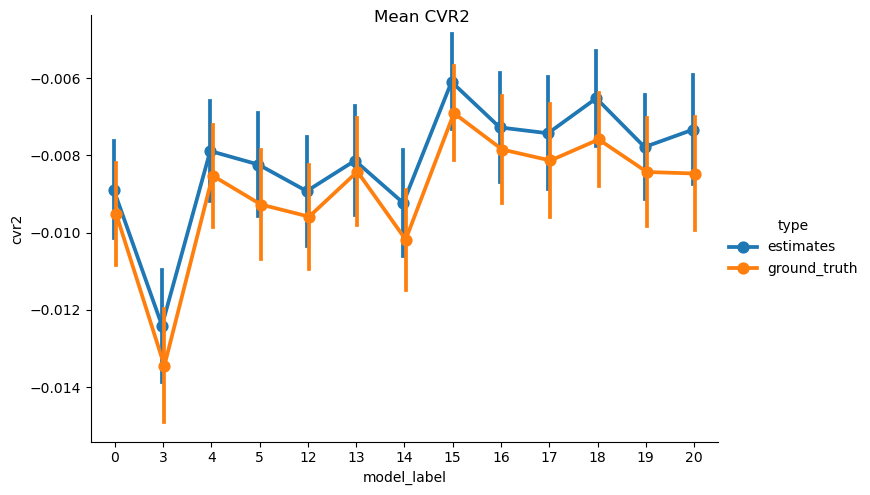

In [30]:
cvr2 = pars[('cvr2', 'nan')].to_frame('cvr2')

cvr2_proportion = cvr2.groupby(['subject', 'model_label', 'type']).median()

sns.catplot(x='model_label', y='cvr2', data=cvr2_proportion.reset_index(), kind='point', errorbar='se', aspect=1.5, 
            hue='type', dodge=True)
plt.suptitle('Mean CVR2')

Text(0.5, 1.0, 'Mean SD ratio (wide/narrow) across subjects, model 15 (ground truth)')

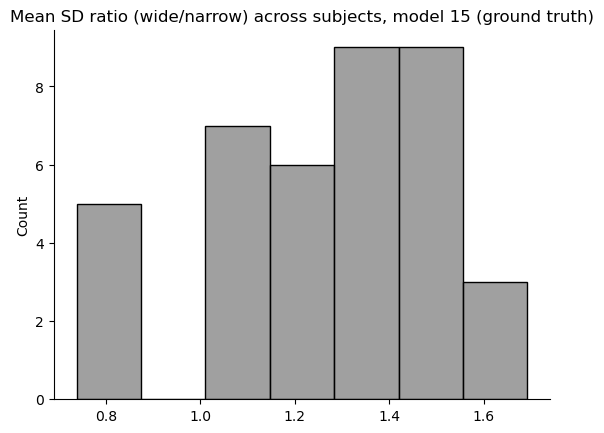

In [17]:
tmp = pars.xs(15, level='model_label', axis=0).xs('ground_truth', level='type', axis=0)

sd_x = tmp[('sd', 'wide')] / tmp[('sd', 'narrow')]

sns.histplot(sd_x.groupby('subject').mean(), color='gray')
sns.despine()

plt.title('Mean SD ratio (wide/narrow) across subjects, model 15 (ground truth)')

Text(0.5, 1.0, 'Mean SD ratio (wide/narrow) across subjects, model 15 (estimates)')

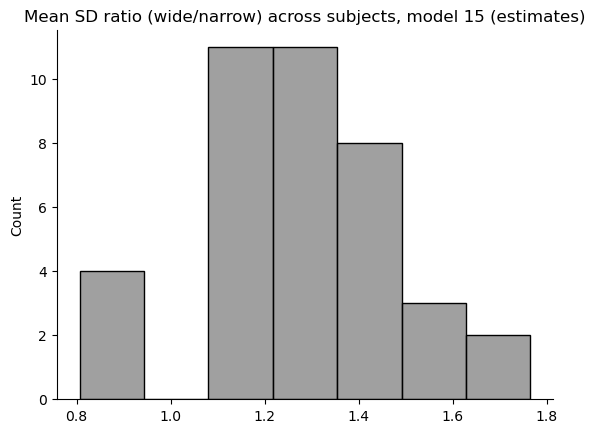

In [18]:
tmp = pars.xs(15, level='model_label', axis=0).xs('estimates', level='type', axis=0)

sd_x = tmp[('sd', 'wide')] / tmp[('sd', 'narrow')]

sns.histplot(sd_x.groupby('subject').mean(), color='gray')
sns.despine()

plt.title('Mean SD ratio (wide/narrow) across subjects, model 15 (estimates)')

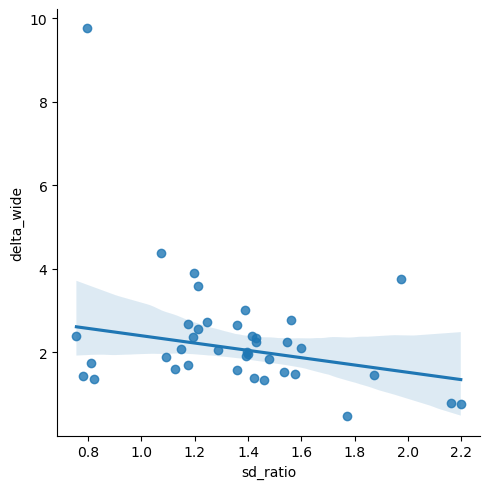

In [106]:
tmp = pars.xs(18, level='model_label', axis=0).xs('ground_truth', level='type', axis=0)

sd_x = (tmp[('sd', 'wide')] / tmp[('sd', 'narrow')]).groupby('subject').mean()
delta_wide = tmp[('delta_wide', 'narrow')].groupby('subject').mean()

# sd_x.join(delta_wide)

sns.lmplot(sd_x.to_frame('sd_ratio').join(delta_wide.to_frame('delta_wide')),
                x='sd_ratio', y='delta_wide', robust=True)

Text(0.5, 0.98, 'Proportion of voxels with CVR2 > 0')

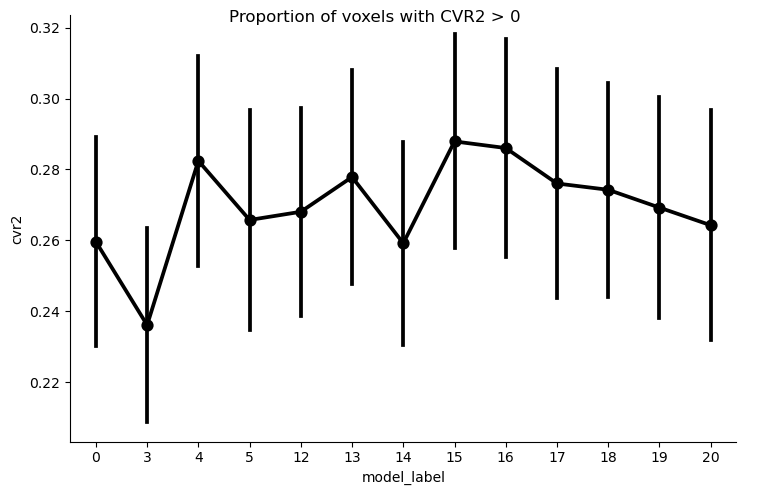

In [31]:
cvr2 = pars[('cvr2', 'nan')].to_frame('cvr2')

cvr2_proportion = cvr2.xs('ground_truth', level='type').groupby(['subject', 'model_label']).apply(lambda x: (x > 0.0).mean())

sns.catplot(x='model_label', y='cvr2', data=cvr2_proportion.reset_index(), kind='point', errorbar='se', aspect=1.5, color='k')
plt.suptitle('Proportion of voxels with CVR2 > 0')

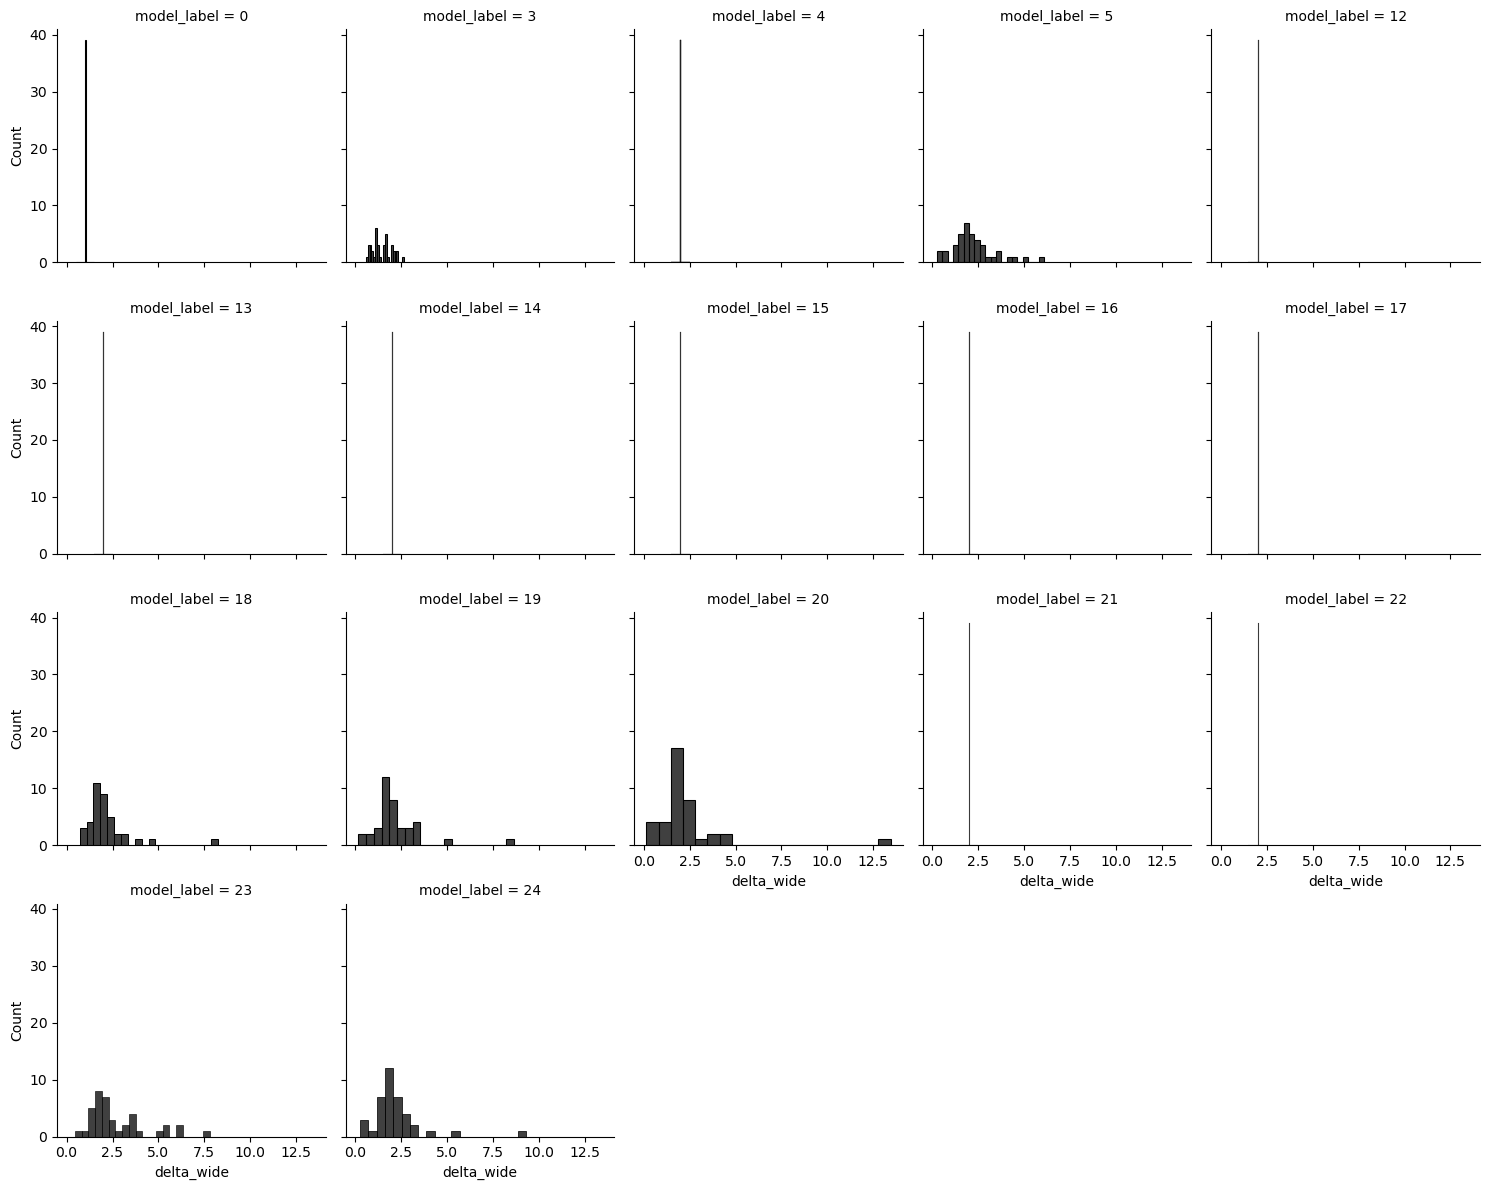

In [107]:
g = sns.FacetGrid(pars[('delta_wide', 'narrow')].groupby(['subject', 'model_label']).mean().to_frame('delta_wide').reset_index(),
                  col='model_label', col_wrap=5)

g.map_dataframe(sns.histplot, x='delta_wide', bins=20, color='k')

In [10]:
pars.xs(13, level='model_label')['baseline_ratio']

range                                narrow      wide
type         subject smoothed                        
ground_truth 1       True     0    0.526025  0.526025
                              1    0.526025  0.526025
                              2    0.526025  0.526025
                              3    0.526025  0.526025
                              4    0.526025  0.526025
...                                     ...       ...
estimates    41      True     689  0.324076  0.324076
                              690  0.324076  0.324076
                              691  0.324076  0.324076
                              692  0.324076  0.324076
                              693  0.324076  0.324076

[61066 rows x 2 columns]

<Axes: xlabel='narrow', ylabel='Count'>

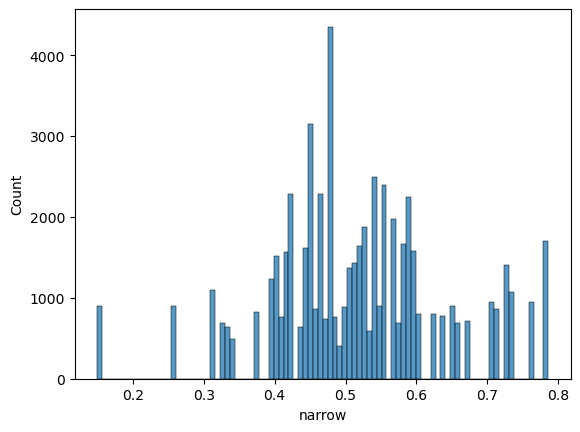

In [11]:
sns.histplot(pars.xs(13, level='model_label')['baseline_ratio']['narrow'])

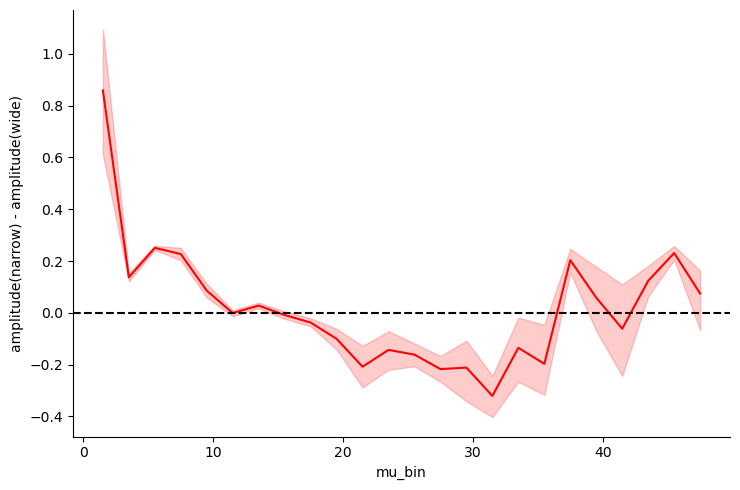

In [12]:
tmp = pars.xs(13, level='model_label')


tmp = tmp[tmp[('cvr2', 'nan')] > 0.0]

amplitude_diff = (tmp[('amplitude', 'narrow')] - tmp[('amplitude', 'wide')]).rename('amplitude(narrow) - amplitude(wide)')
mu_bin = pd.cut(tmp[('mu', 'narrow')], np.arange(.5, 50, 2.0)).apply(lambda x: x.mid).rename('mu_bin')

tmp = pd.concat((amplitude_diff, mu_bin), axis=1)

sns.relplot(x='mu_bin', y='amplitude(narrow) - amplitude(wide)', data=tmp, kind='line', aspect=1.5, color='r')

plt.axhline(0, color='k', linestyle='--')

(0.0, 2.0)

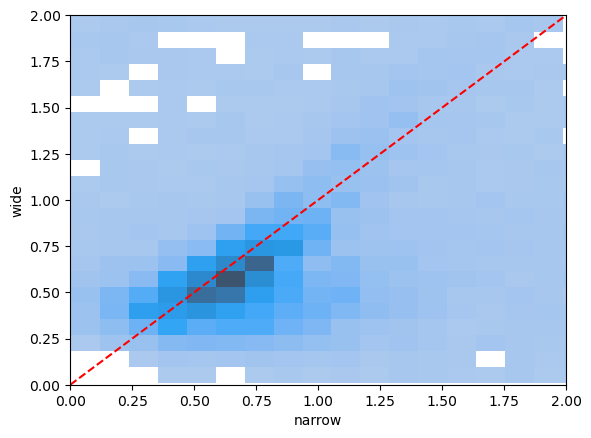

In [21]:
tmp = pars.xs(13, level='model_label')
tmp = tmp[tmp[('cvr2', 'nan')] > 0.0]


sns.histplot(x='narrow', y='wide', data=tmp['amplitude'].reset_index(), bins=50,)
plt.plot([0, 3], [0,3 ], color='r', linestyle='--')
plt.xlim(0, 2)
plt.ylim(0, 2)

<Axes: xlabel='narrow', ylabel='wide'>

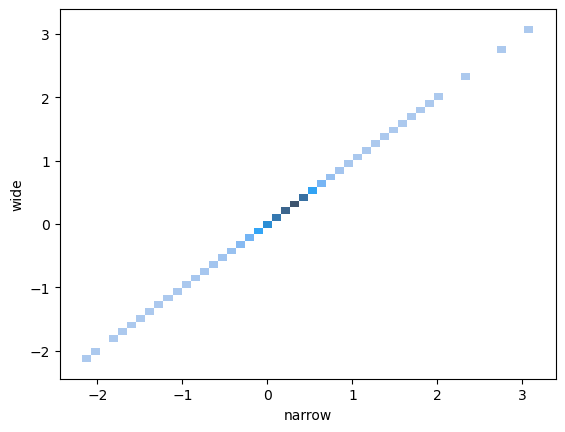

In [22]:
tmp = pars.xs(13, level='model_label')
tmp = tmp[tmp[('cvr2', 'nan')] > 0.0]


sns.histplot(x='narrow', y='wide', data=tmp['baseline'].reset_index(), bins=50,)
# plt.plot([0, 3], [0,3 ], color='r', linestyle='--')
# plt.xlim(0, 2)
# plt.ylim(0, 2)

Text(0.5, 0, 'Subjectwise baseline ratio')

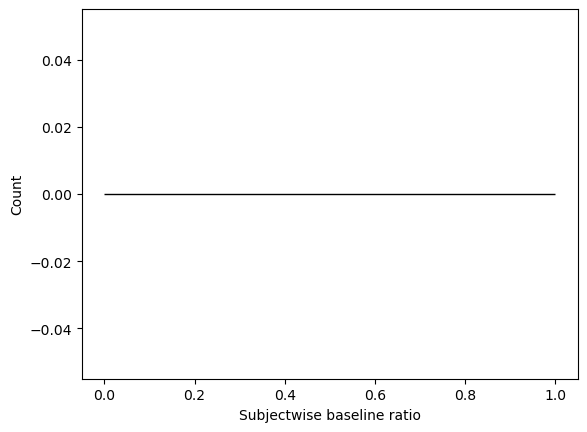

In [ ]:
sns.histplot(pars.xs(14, level='model_label')['baseline_ratio']['narrow'].groupby(['subject']).mean())
plt.xlabel('Subjectwise baseline ratio')

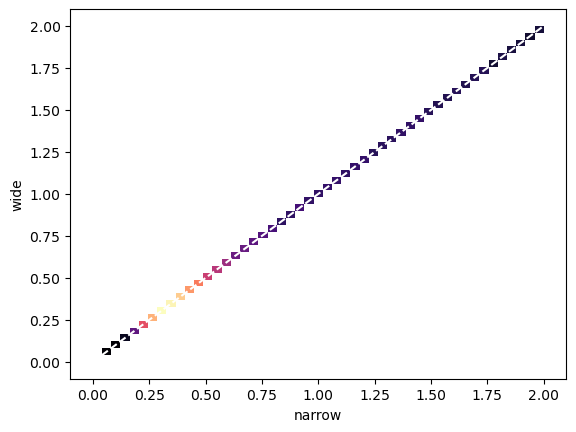

In [96]:
tmp = pars.loc['ground_truth']

tmp = tmp.loc[tmp[('cvr2', 'nan')] > 0.0]

sns.histplot(x='narrow', y='wide', data=tmp.xs(3, level='model_label')['amplitude'], bins=[np.linspace(0, 2, 50), np.linspace(0, 2, 50)], cmap='magma')
plt.plot([0, 2], [0, 2], color='white', linestyle='--')

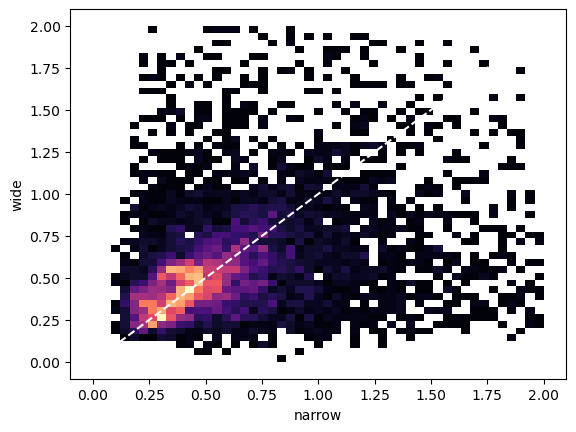

In [33]:
tmp = pars.loc['ground_truth']

tmp = tmp.loc[tmp[('cvr2', 'nan')] > 0.0]

sns.histplot(x='narrow', y='wide', data=tmp.xs(10, level='model_label')['amplitude'], bins=[np.linspace(0, 2, 50), np.linspace(0, 2, 50)], cmap='magma')
plt.plot([0, 2], [0, 2], color='white', linestyle='--')

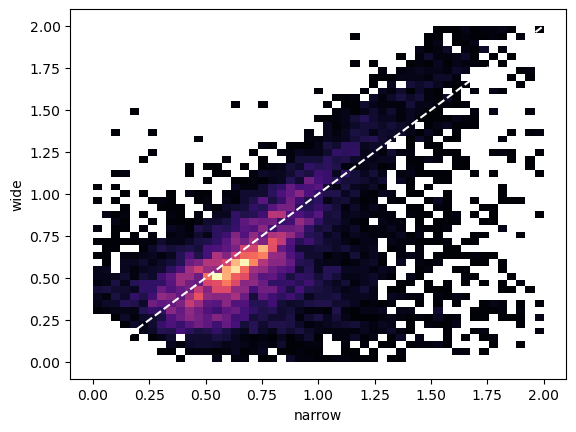

In [78]:
tmp = pars.loc['ground_truth']

tmp = tmp.loc[tmp[('cvr2', 'nan')] > 0.0]

sns.histplot(x='narrow', y='wide', data=tmp.xs(13, level='model_label')['amplitude'], bins=[np.linspace(0, 2, 50), np.linspace(0, 2, 50)], cmap='magma')
plt.plot([0, 2], [0, 2], color='white', linestyle='--')

(0.0, 2.0)

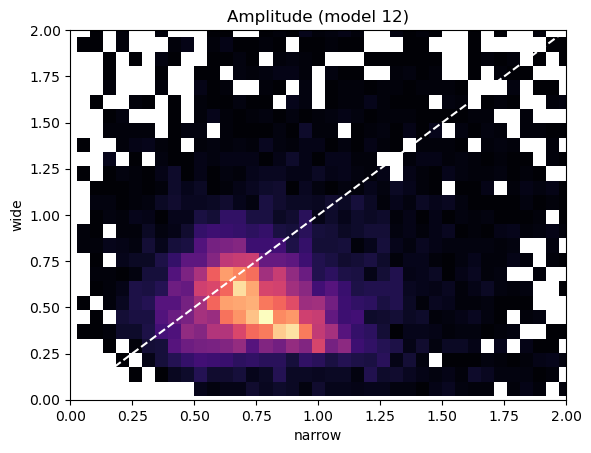

In [44]:
tmp = pars.loc['ground_truth']

tmp = tmp.loc[tmp[('cvr2', 'nan')] > 0.0]

sns.histplot(x='narrow', y='wide', data=tmp.xs(12, level='model_label')['amplitude'], bins=100, cmap='magma')
plt.plot([0, 2], [0, 2], color='white', linestyle='--')

plt.title('Amplitude (model 12)')

plt.xlim(0, 2)
plt.ylim(0, 2)

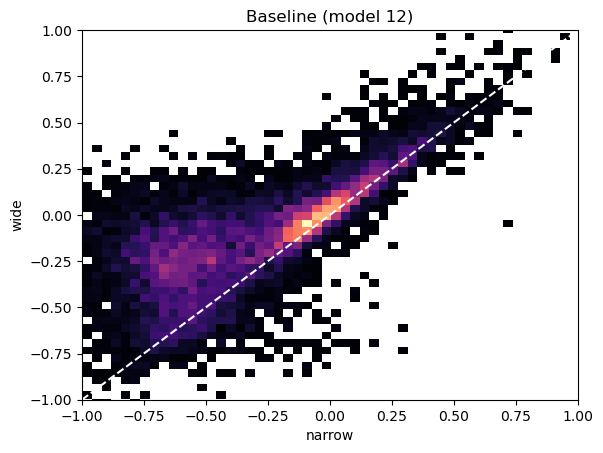

In [42]:
tmp = pars.loc['ground_truth']

tmp = tmp.loc[tmp[('cvr2', 'nan')] > 0.0]

sns.histplot(x='narrow', y='wide', data=tmp.xs(12, level='model_label')['baseline'], bins=100, cmap='magma')
# plt.plot([0, 2], [0, 2], color='white', linestyle='--')

plt.title('Baseline (model 12)')

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.plot([-1, 1], [-1, 1], color='white', linestyle='--')

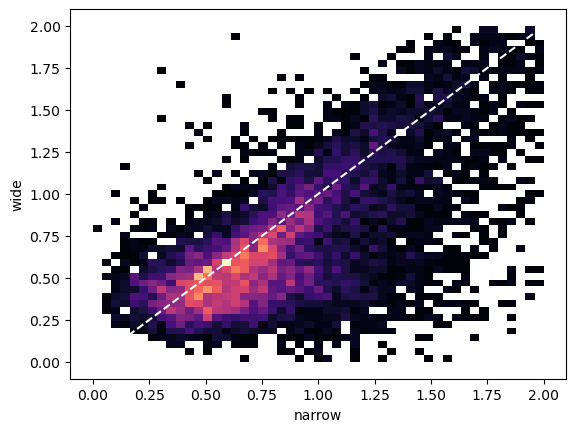

In [77]:
tmp = pars.loc['ground_truth']

tmp = tmp.loc[tmp[('cvr2', 'nan')] > 0.0]

sns.histplot(x='narrow', y='wide', data=tmp.xs(11, level='model_label')['amplitude'], bins=[np.linspace(0, 2, 50), np.linspace(0, 2, 50)], cmap='magma')
plt.plot([0, 2], [0, 2], color='white', linestyle='--')

(0.0, 2.5)

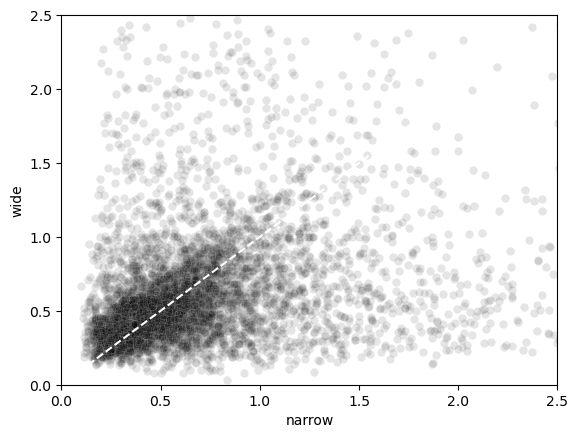

In [100]:
tmp = pars.loc['ground_truth']

tmp = tmp.loc[tmp[('cvr2', 'nan')] > 0.0]

sns.scatterplot(x='narrow', y='wide', data=tmp.xs(10, level='model_label')['amplitude'], color='k', alpha=0.1)
plt.plot([0, 2], [0, 2], color='white', linestyle='--')

plt.xlim(0, 2.5)
plt.ylim(0, 2.5)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_21409/2847871086.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  sns.catplot(x='range', y='amplitude', data=tmp.xs(10, level='model_label')[['amplitude']].stack().groupby(['subject', 'range']).mean().reset_index(), kind='swarm', errorbar='se', aspect=1.5, color='k')


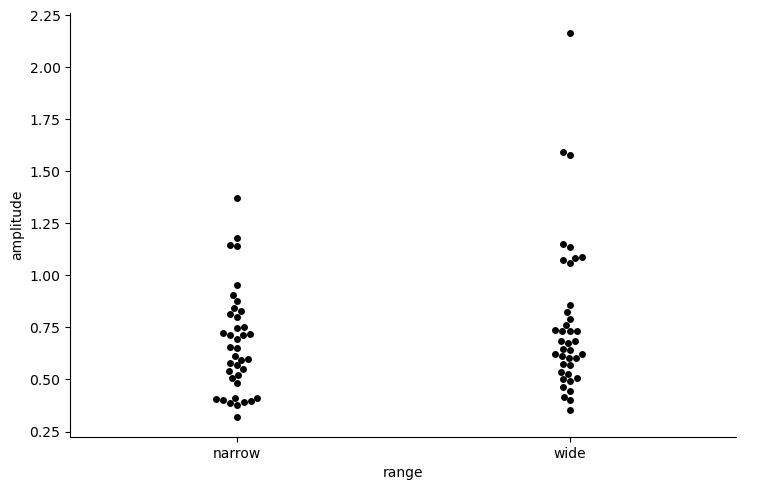

In [101]:
sns.catplot(x='range', y='amplitude', data=tmp.xs(10, level='model_label')[['amplitude']].stack().groupby(['subject', 'range']).mean().reset_index(), kind='swarm', errorbar='se', aspect=1.5, color='k')


# pg.ttest

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_21409/251628080.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  sns.catplot(x='range', y='amplitude', data=tmp.xs(11, level='model_label')[['amplitude']].stack().groupby(['subject', 'range']).mean().reset_index(), kind='point', errorbar='se', aspect=1.5, color='k')


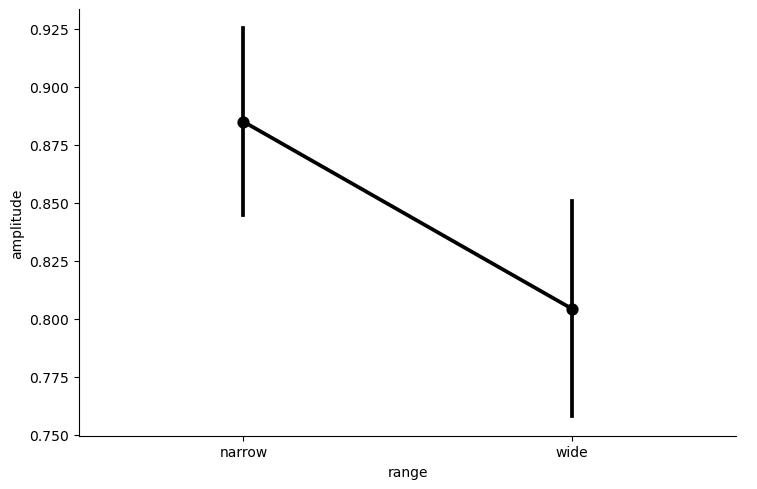

In [103]:
sns.catplot(x='range', y='amplitude', data=tmp.xs(11, level='model_label')[['amplitude']].stack().groupby(['subject', 'range']).mean().reset_index(), kind='point', errorbar='se', aspect=1.5, color='k')


# pg.ttest

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_21409/2177730219.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  sns.catplot(x='range', y='mu', data=tmp.xs(3, level='model_label')[['mu']].stack().groupby(['subject', 'range']).mean().reset_index(), kind='point', errorbar='se', aspect=1.5, color='k')


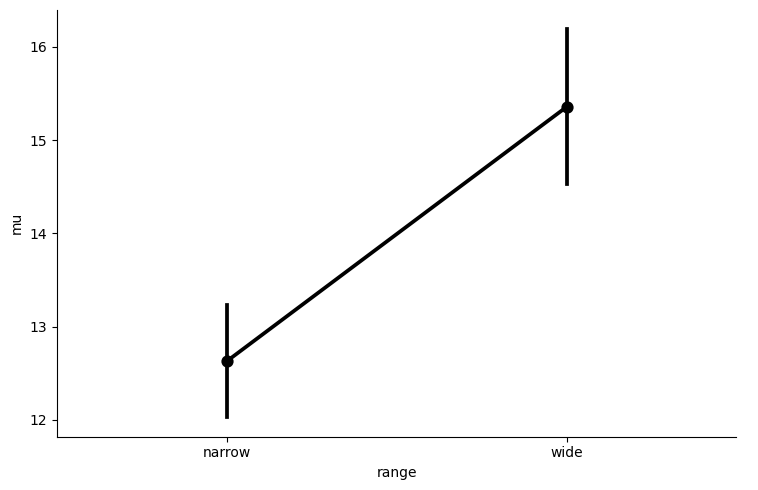

In [104]:
sns.catplot(x='range', y='mu', data=tmp.xs(3, level='model_label')[['mu']].stack().groupby(['subject', 'range']).mean().reset_index(), kind='point', errorbar='se', aspect=1.5, color='k')


# pg.ttest

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_21409/604290846.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  sns.catplot(x='range', y='mu', data=tmp.xs(11, level='model_label')[['mu']].stack().groupby(['subject', 'range']).mean().reset_index(), kind='point', errorbar='se', aspect=1.5, color='k')


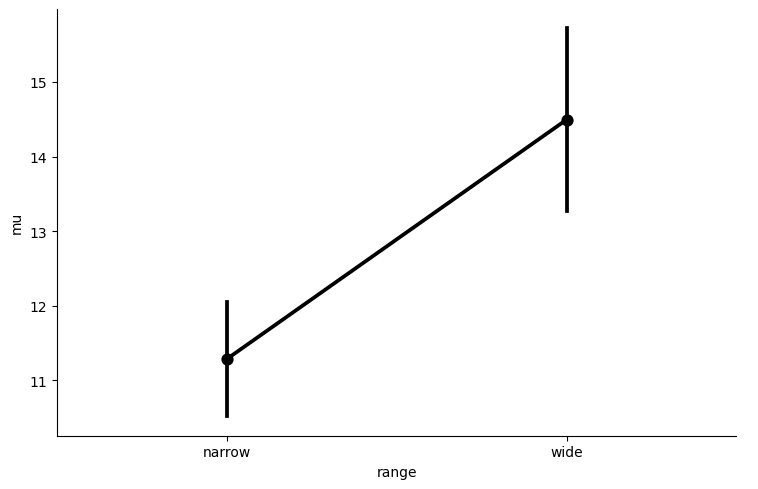

In [106]:
sns.catplot(x='range', y='mu', data=tmp.xs(11, level='model_label')[['mu']].stack().groupby(['subject', 'range']).mean().reset_index(), kind='point', errorbar='se', aspect=1.5, color='k')


# pg.ttest

In [107]:
import pingouin as pg
tmp = pars.loc['ground_truth']

tmp = tmp.loc[tmp[('cvr2', 'nan')] > 0.0].groupby('subject').mean()
pg.ttest(tmp[('amplitude', 'narrow')], tmp[('amplitude', 'wide')], paired=True, alternative='two-sided',)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.124938,38,two-sided,0.901231,"[-0.04, 0.04]",0.011031,0.174,0.050517


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_18744/3343501812.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  g = sns.FacetGrid(pars.xs('ground_truth', level='type', drop_level=False)[pars[('cvr2', 'nan')] > 0.0][('mu')].reset_index(), col='model_label', col_wrap=3)


Text(0.5, 1.05, 'Ground truth narrow vs wide mu')

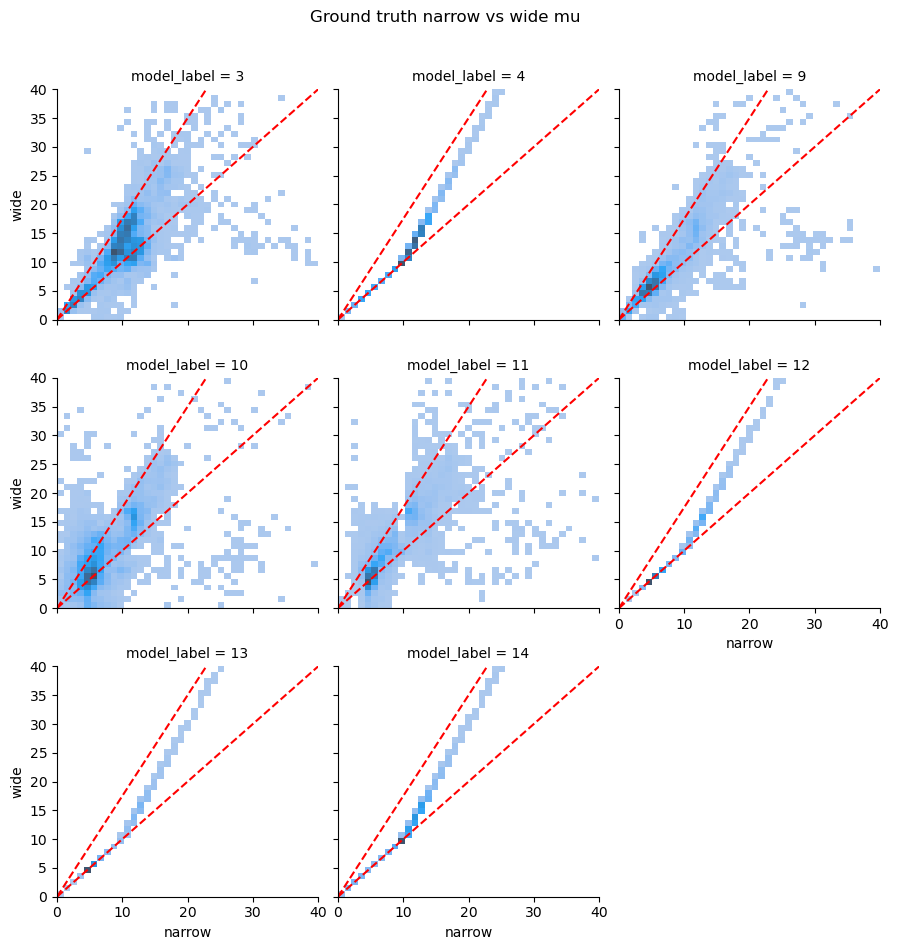

In [45]:
g = sns.FacetGrid(pars.xs('ground_truth', level='type', drop_level=False)[pars[('cvr2', 'nan')] > 0.0][('mu')].reset_index(), col='model_label', col_wrap=3)



g.map(sns.histplot, 'narrow', 'wide', bins=[np.linspace(0, 40, 40), np.linspace(0, 40, 40)])


slope = 1.
g.map(lambda *args, **kwargs: plt.plot([0, 40], [0, 10 + slope*(40-10)], 'r--'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([0, 40], [0, 10 + slope*(40-10)], 'r--'))

# g.set_titles('Model {col_name} ({row_name})')

g.set(xlim=(0, 40), ylim=(0, 40))


plt.suptitle('Ground truth narrow vs wide mu', y=1.05)

In [110]:
pars.xs(11, level='model_label')

parameter                       mu                   sd             alpha  \
range                       narrow       wide    narrow      wide  narrow   
type         subject                                                        
ground_truth 1       0    5.807847   6.487105  0.341773  0.341773  0.0001   
                     1    4.466916   2.990169  0.523785  0.523785  0.0001   
                     2    3.584677   1.447016  0.690191  0.690191  0.0001   
                     3    3.771967   1.743201  0.763907  0.763907  0.0001   
                     4    5.760426   7.090590  0.415370  0.415370  0.0001   
...                            ...        ...       ...       ...     ...   
             41      689  8.522230  10.942048  1.792621  1.792621  0.0001   
                     690  7.425164   3.351550  4.480523  4.480523  0.0001   
                     691  8.542289  12.625977  1.709303  1.709303  0.0001   
                     692  5.136656   5.182719  0.854036  0.854036  0.0001   
                     693  8.326820  12.987878  1.803737  1.803737  0.0001   

parameter                        delta_wide           lower_bound_range        \
range                       wide     narrow      wide            narrow  wide   
type         subject                                                            
ground_truth 1       0    0.0001   0.837969  0.837969              10.0  10.0   
                     1    0.0001   1.266894  1.266894              10.0  10.0   
                     2    0.0001   1.333212  1.333212              10.0  10.0   
                     3    0.0001   1.325747  1.325747              10.0  10.0   
                     4    0.0001   0.686251  0.686251              10.0  10.0   
...                          ...        ...       ...               ...   ...   
             41      689  0.0001  -0.637479 -0.637479              10.0  10.0   
                     690  0.0001   2.582087  2.582087              10.0  10.0   
                     691  0.0001  -1.801438 -1.801438              10.0  10.0   
                     692  0.0001   0.990529  0.990529              10.0  10.0   
                     693  0.0001  -1.785749 -1.785749              10.0  10.0   

parameter                amplitude            baseline                  r2  \
range                       narrow      wide    narrow      wide       nan   
type         subject                                                         
ground_truth 1       0    0.880615  0.911313  0.368120  0.368120  0.007436   
                     1    0.956245  0.863453 -0.034537 -0.034537  0.004456   
                     2    0.642238  0.585414 -0.180289 -0.180289  0.003727   
                     3    0.634260  0.538241 -0.012523 -0.012523  0.006952   
                     4    0.642490  0.560907  0.201836  0.201836  0.006984   
...                            ...       ...       ...       ...       ...   
             41      689  1.057996  1.160509 -0.145538 -0.145538  0.025207   
                     690  0.477323  0.477350  0.064586  0.064586  0.003253   
                     691  1.202453  1.228092 -0.301375 -0.301375  0.025756   
                     692  0.446372  0.289493  0.005475  0.005475  0.015265   
                     693  1.119248  1.105441 -0.421362 -0.421362  0.012735   

parameter                     cvr2  
range                          nan  
type         subject                
ground_truth 1       0   -0.026778  
                     1   -0.020865  
                     2   -0.015648  
                     3   -0.016179  
                     4   -0.026192  
...                            ...  
             41      689  0.008810  
                     690 -0.027996  
                     691  0.010771  
                     692 -0.014606  
                     693  0.001941  

[30533 rows x 16 columns]